# 📊 House Prices — 06. Visualização & Storytelling
**Responsável:** Natalia  
**Dataset:** [Kaggle - House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)  
**Objetivo:** Construir visualizações que contam a história dos dados e dos resultados do projeto.

##  0. Importações e Configuração Visual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Estilo padrão dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


##  1. Carregamento dos Dados

In [2]:

df = pd.read_csv(r"../data/train.csv")
print(f'Shape do dataset: {df.shape}')
print(f'Colunas: {df.shape[1]} | Linhas: {df.shape[0]}')
df.head()


Shape do dataset: (1460, 81)
Colunas: 81 | Linhas: 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
##  Storytelling — Parte 1: Conhecendo os Dados

> Antes de construir qualquer modelo, precisamos entender **o que os dados nos contam**.
> O dataset contém informações sobre casas vendidas em Ames, Iowa (EUA), com dezenas de características
> como tamanho, qualidade, localização e ano de construção.
> Nossa variável-alvo é o **SalePrice** — o preço final de venda de cada casa.

##  2. Distribuições das Variáveis Principais

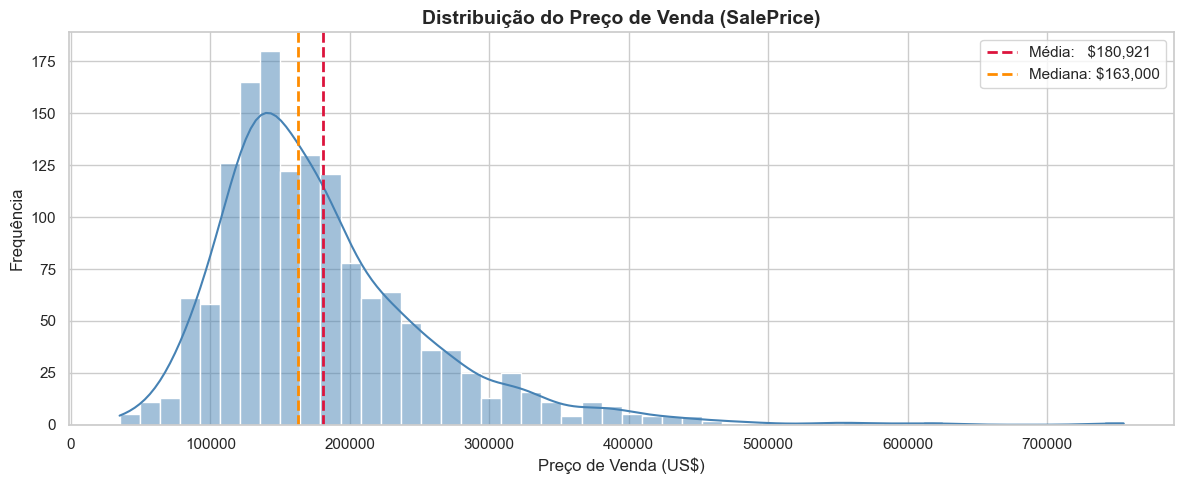

✅ Gráfico salvo!


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(df['SalePrice'], kde=True, color='steelblue', bins=50, ax=ax)

ax.axvline(df['SalePrice'].mean(),   color='crimson',    linestyle='--', linewidth=2, label=f"Média:   ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='darkorange', linestyle='--', linewidth=2, label=f"Mediana: ${df['SalePrice'].median():,.0f}")

ax.set_title('Distribuição do Preço de Venda (SalePrice)', fontsize=14, fontweight='bold')
ax.set_xlabel('Preço de Venda (US$)')
ax.set_ylabel('Frequência')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/plot_distribuicao_saleprice.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

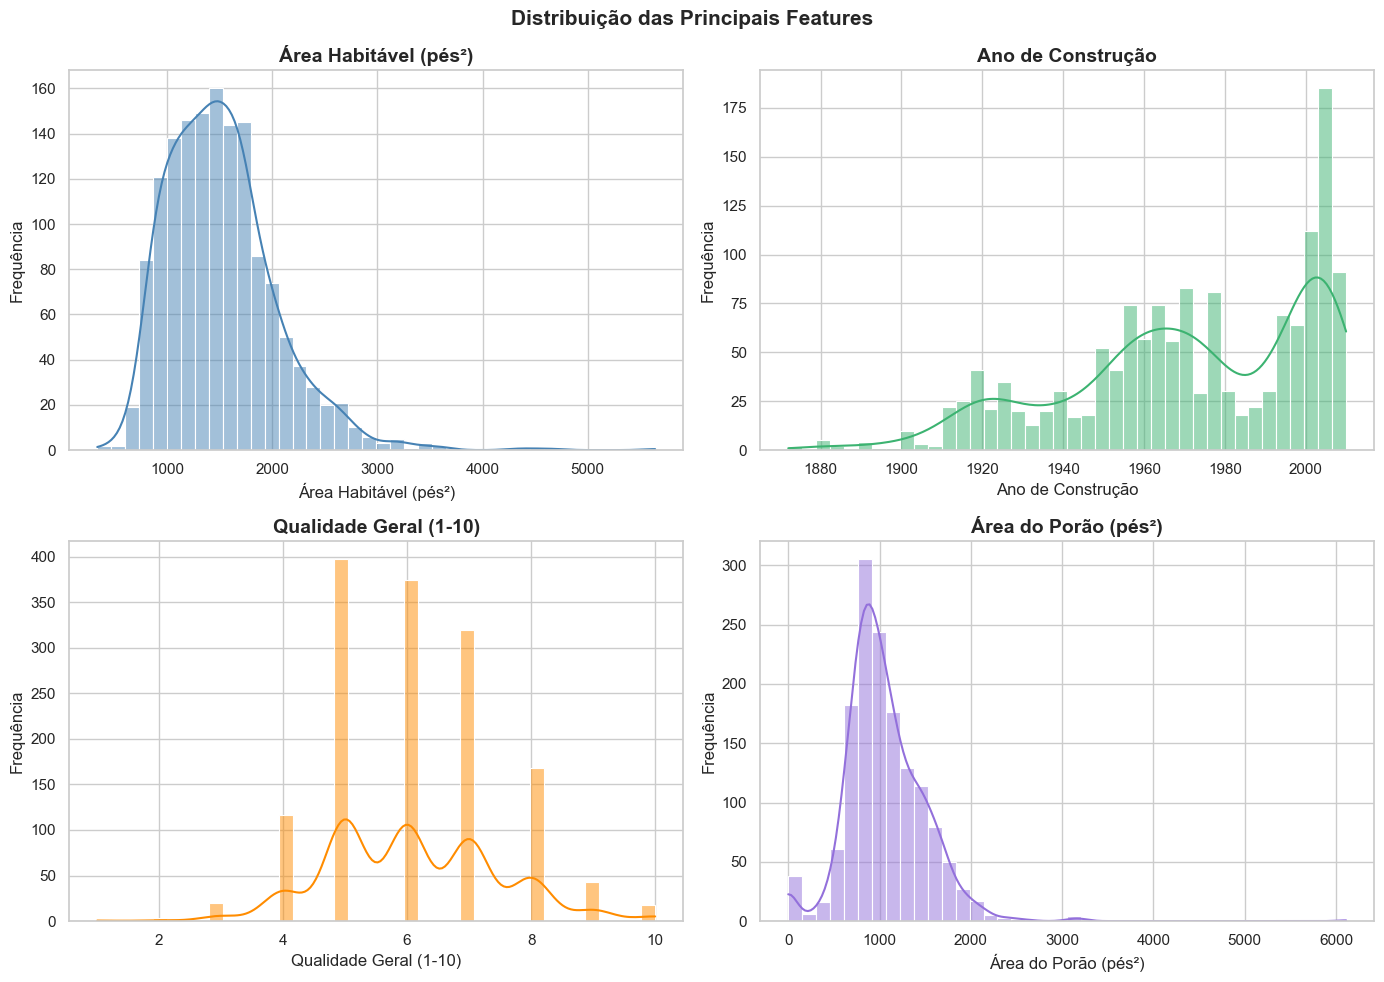

✅ Gráfico salvo!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = {
    'GrLivArea':    'Área Habitável (pés²)',
    'YearBuilt':    'Ano de Construção',
    'OverallQual':  'Qualidade Geral (1-10)',
    'TotalBsmtSF':  'Área do Porão (pés²)'
}

cores = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']

for ax, (col, label), cor in zip(axes.flatten(), features.items(), cores):
    sns.histplot(df[col].dropna(), kde=True, color=cor, bins=40, ax=ax)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequência')

plt.suptitle('Distribuição das Principais Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_distribuicoes_features.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

---
##  Storytelling — Parte 2: O Preço das Casas

> O preço de venda apresenta uma distribuição com **assimetria à direita** —
> a maioria das casas se concentra entre US$ 100.000 e US$ 250.000, mas algumas casas de alto valor
> puxam a média (~US$ 180.921) para acima da mediana (~US$ 163.000). Isso é típico do mercado imobiliário.

> A **área habitável** (GrLivArea) varia amplamente, de menos de 500 até mais de 4.000 pés²,
> com a maioria concentrada entre 800 e 2.000 pés². A **qualidade geral** (OverallQual)
> apresenta distribuição mais uniforme, com pico na faixa 5–7 (qualidade média a boa).
> O **ano de construção** revela duas ondas de crescimento: casas históricas (~1900–1960)
> e um boom recente de construções pós-2000.

##  3. Heatmap de Correlações

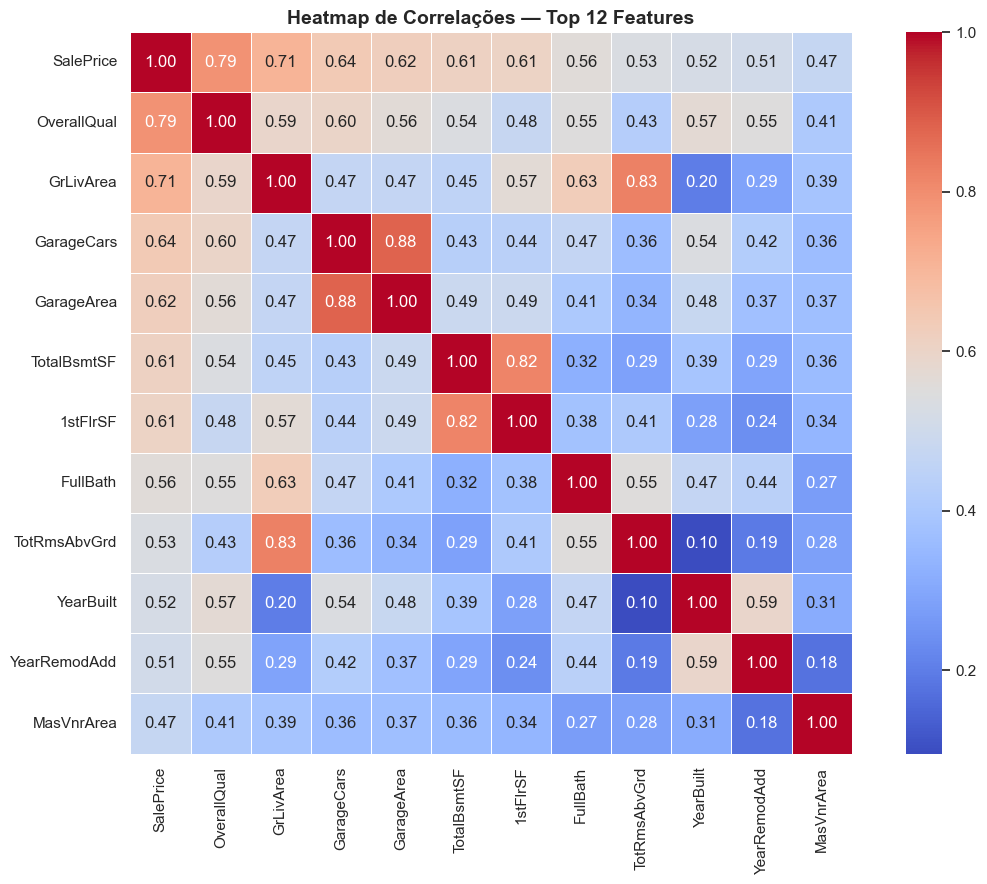

✅ Gráfico salvo!


In [5]:

df_num = df.select_dtypes(include=[np.number]).fillna(0)
top_corr = df_num.corr()['SalePrice'].abs().sort_values(ascending=False).head(12).index

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    df_num[top_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Heatmap de Correlações — Top 12 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_heatmap_correlacoes.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

---
## Storytelling — Parte 3: O Que Mais Influencia o Preço?

> O heatmap revela que as variáveis com **maior correlação** com o preço de venda são:
> `OverallQual` (r ≈ 0.79), `GrLivArea` (r ≈ 0.71), `GarageCars` (r ≈ 0.64),
> `GarageArea` (r ≈ 0.62) e `TotalBsmtSF` (r ≈ 0.61).

> Isso faz sentido intuitivo: casas maiores, de melhor qualidade, com garagem ampla
> e porões espaçosos são mais valorizadas. Há também alta correlação entre
> `GarageCars` e `GarageArea` (r ≈ 0.88), indicando redundância entre essas features —
> algo relevante para a modelagem, pois multicolinearidade pode afetar a regressão linear.

##  4. Scatter Plots — Relação entre Features e Preço

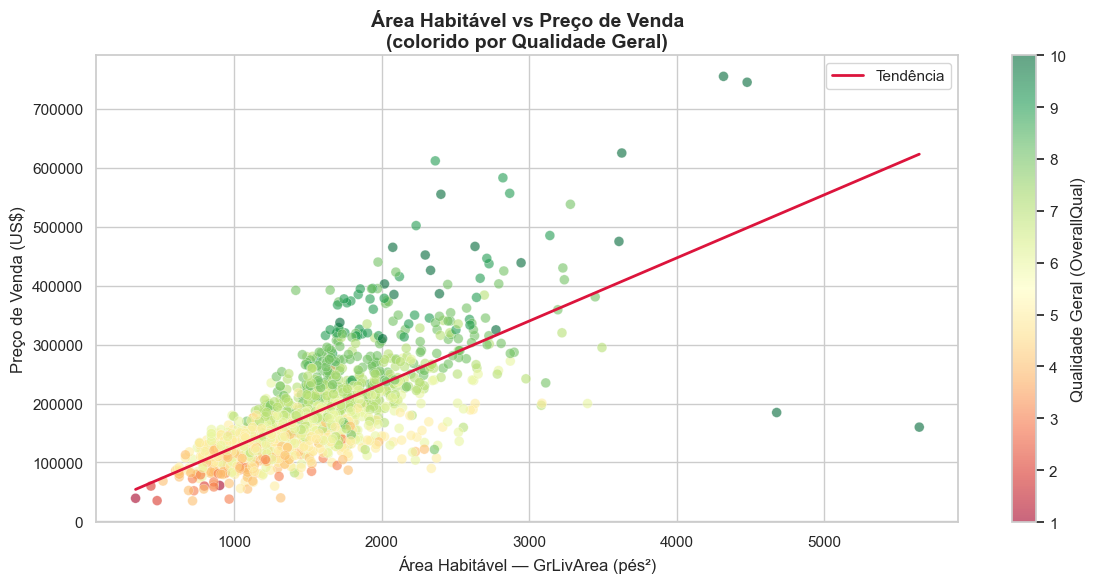

✅ Gráfico salvo!


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    df['GrLivArea'],
    df['SalePrice'],
    c=df['OverallQual'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.3,
    s=50
)

# Linha de tendência
m, b = np.polyfit(df['GrLivArea'], df['SalePrice'], 1)
x_line = np.linspace(df['GrLivArea'].min(), df['GrLivArea'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label='Tendência')

plt.colorbar(scatter, ax=ax, label='Qualidade Geral (OverallQual)')
ax.set_title('Área Habitável vs Preço de Venda\n(colorido por Qualidade Geral)', fontweight='bold')
ax.set_xlabel('Área Habitável — GrLivArea (pés²)')
ax.set_ylabel('Preço de Venda (US$)')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/plot_scatter_area_preco.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

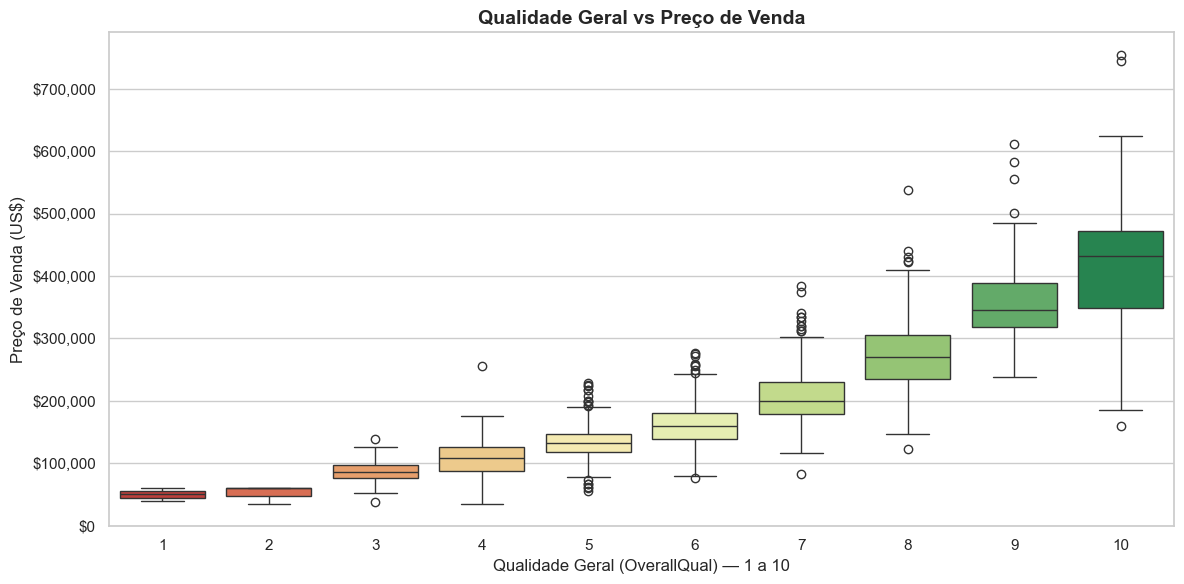

✅ Gráfico salvo!


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='OverallQual',
    y='SalePrice',
    palette='RdYlGn',
    ax=ax
)

ax.set_title('Qualidade Geral vs Preço de Venda', fontweight='bold')
ax.set_xlabel('Qualidade Geral (OverallQual) — 1 a 10')
ax.set_ylabel('Preço de Venda (US$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../plots/plot_boxplot_qualidade_preco.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

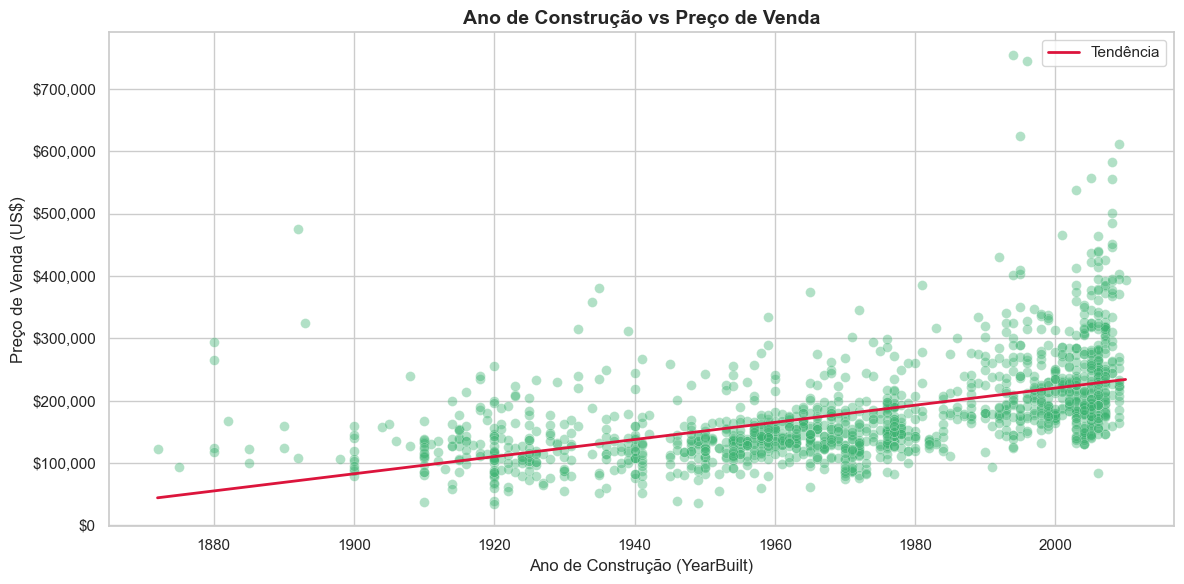

✅ Gráfico salvo!


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    df['YearBuilt'],
    df['SalePrice'],
    alpha=0.4,
    color='mediumseagreen',
    edgecolors='white',
    linewidth=0.3,
    s=50
)

# Linha de tendência
m, b = np.polyfit(df['YearBuilt'], df['SalePrice'], 1)
x_line = np.linspace(df['YearBuilt'].min(), df['YearBuilt'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label='Tendência')

ax.set_title('Ano de Construção vs Preço de Venda', fontweight='bold')
ax.set_xlabel('Ano de Construção (YearBuilt)')
ax.set_ylabel('Preço de Venda (US$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig('../plots/plot_scatter_ano_preco.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

---
##  Storytelling — Parte 4: Padrões Visuais

> Os scatter plots confirmam o que a correlação indicava:
> - **Área habitável** tem relação linear positiva clara com o preço — cada pé² adicional contribui com aproximadamente US$ 107 ao valor do imóvel
> - **Qualidade geral** é talvez o fator mais determinante — casas de qualidade 9–10 ultrapassam US$ 400.000, enquanto as de qualidade 4–5 raramente passam de US$ 150.000 (diferença de ~3x)
> - **Ano de construção** mostra que casas mais recentes (pós-2000) tendem a ser mais caras, mas com maior dispersão de preços, refletindo a variedade de padrões construtivos modernos

> A combinação entre qualidade e tamanho explica a maior parte da variação nos preços.
> Casas grandes com qualidade baixa ou casas pequenas com qualidade alta representam
> exceções interessantes que desafiam os modelos lineares.

## 5. Painel Consolidado

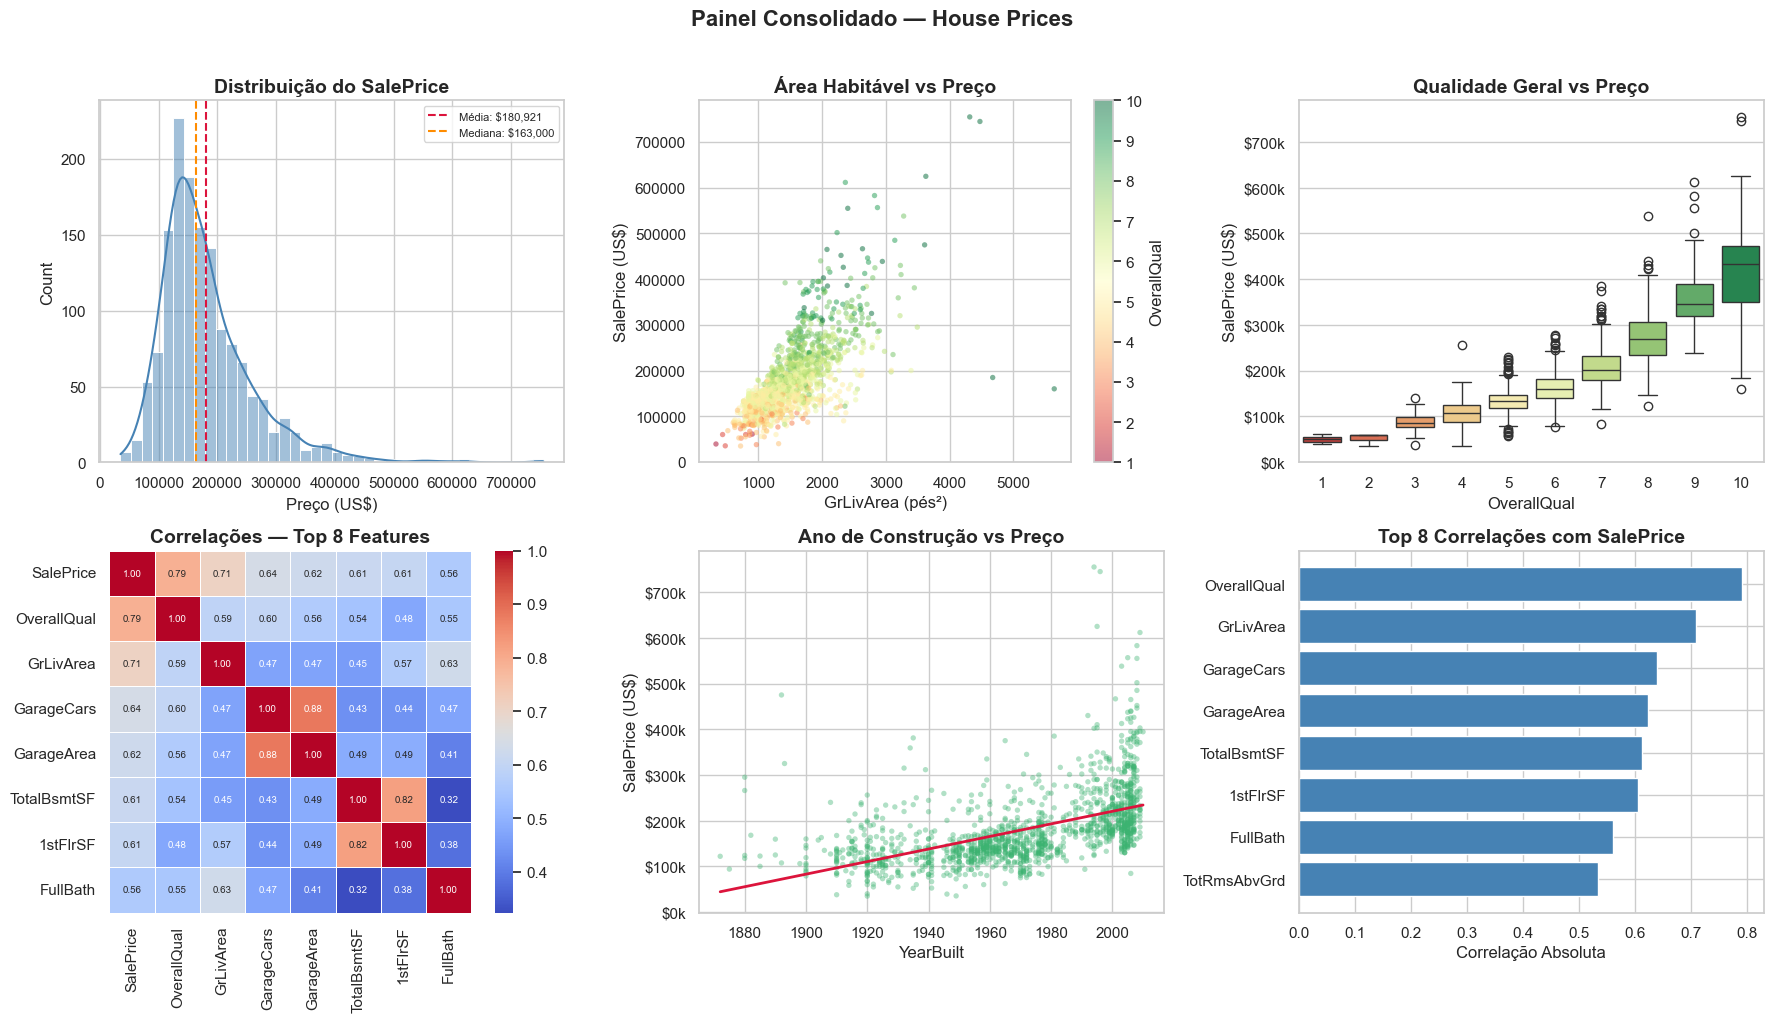

✅ Painel salvo!


In [9]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Painel Consolidado — House Prices', fontsize=16, fontweight='bold', y=1.01)

# ── [0,0] Distribuição SalePrice ──
ax1 = fig.add_subplot(2, 3, 1)
sns.histplot(df['SalePrice'], kde=True, color='steelblue', bins=40, ax=ax1)
ax1.axvline(df['SalePrice'].mean(),   color='crimson',   linestyle='--', linewidth=1.5, label=f"Média: ${df['SalePrice'].mean():,.0f}")
ax1.axvline(df['SalePrice'].median(), color='darkorange', linestyle='--', linewidth=1.5, label=f"Mediana: ${df['SalePrice'].median():,.0f}")
ax1.set_title('Distribuição do SalePrice', fontweight='bold')
ax1.set_xlabel('Preço (US$)')
ax1.legend(fontsize=8)

# ── [0,1] Scatter GrLivArea x SalePrice ──
ax2 = fig.add_subplot(2, 3, 2)
sc = ax2.scatter(df['GrLivArea'], df['SalePrice'], c=df['OverallQual'],
                 cmap='RdYlGn', alpha=0.5, s=15, edgecolors='none')
plt.colorbar(sc, ax=ax2, label='OverallQual')
ax2.set_title('Área Habitável vs Preço', fontweight='bold')
ax2.set_xlabel('GrLivArea (pés²)')
ax2.set_ylabel('SalePrice (US$)')

# ── [0,2] Boxplot OverallQual ──
ax3 = fig.add_subplot(2, 3, 3)
sns.boxplot(data=df, x='OverallQual', y='SalePrice', palette='RdYlGn', ax=ax3)
ax3.set_title('Qualidade Geral vs Preço', fontweight='bold')
ax3.set_xlabel('OverallQual')
ax3.set_ylabel('SalePrice (US$)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ── [1,0] Heatmap mini ──
ax4 = fig.add_subplot(2, 3, 4)
top8 = df.select_dtypes(include=[np.number]).fillna(0).corr()['SalePrice'].abs().sort_values(ascending=False).head(8).index
sns.heatmap(df[top8].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax4, annot_kws={'size': 7})
ax4.set_title('Correlações — Top 8 Features', fontweight='bold')

# ── [1,1] Scatter YearBuilt ──
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(df['YearBuilt'], df['SalePrice'], alpha=0.4, color='mediumseagreen', s=15, edgecolors='none')
m, b = np.polyfit(df['YearBuilt'], df['SalePrice'], 1)
x_line = np.linspace(df['YearBuilt'].min(), df['YearBuilt'].max(), 100)
ax5.plot(x_line, m * x_line + b, color='crimson', linewidth=2)
ax5.set_title('Ano de Construção vs Preço', fontweight='bold')
ax5.set_xlabel('YearBuilt')
ax5.set_ylabel('SalePrice (US$)')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ── [1,2] Correlações com SalePrice (barras) ──
ax6 = fig.add_subplot(2, 3, 6)
top_corr = df.select_dtypes(include=[np.number]).fillna(0).corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(8)
colors = ['steelblue' if v > 0 else 'crimson' for v in top_corr]
ax6.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
ax6.set_title('Top 8 Correlações com SalePrice', fontweight='bold')
ax6.set_xlabel('Correlação Absoluta')

plt.tight_layout()
plt.savefig('../plots/plot_painel_consolidado.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Painel salvo!')

---
## 6. Resultados Consolidados dos Modelos

Nesta seção, reunimos os principais resultados de cada etapa de modelagem para oferecer uma visão integrada do que foi alcançado no projeto.

### 6.1 Performance dos Modelos Supervisionados

Comparamos todas as métricas de regressão e classificação em um único painel.

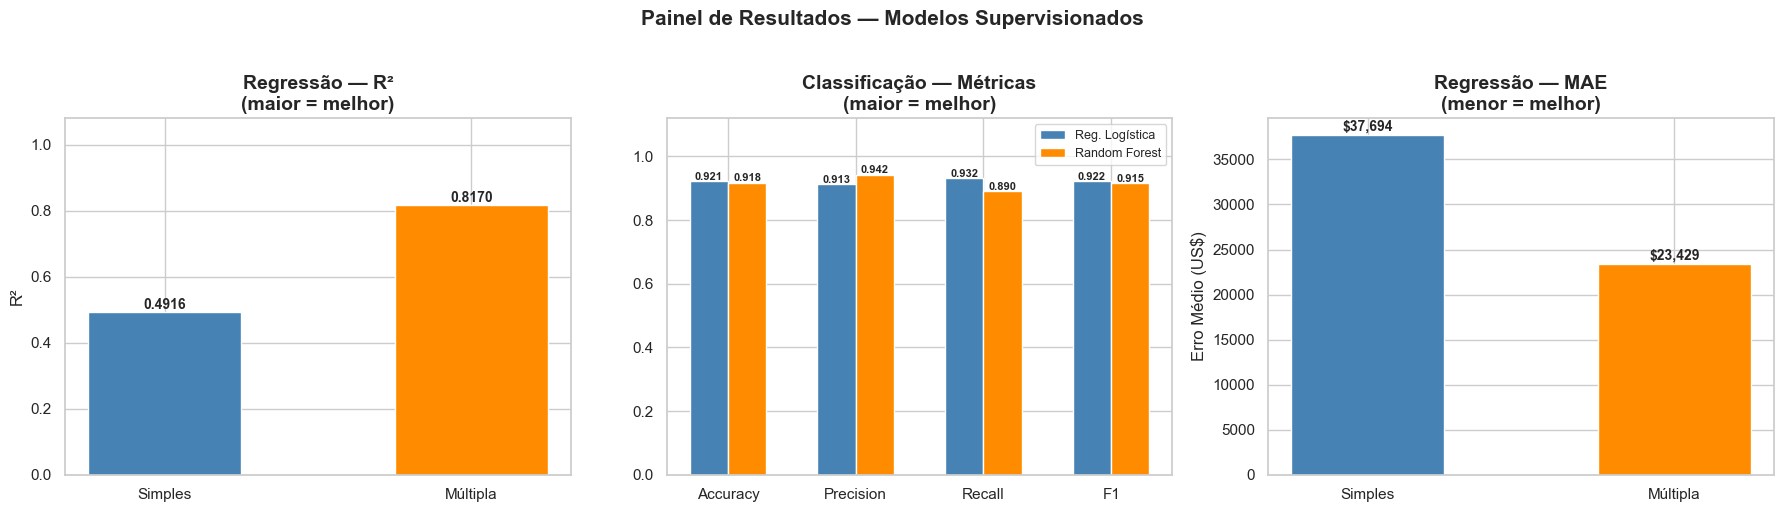

✅ Gráfico salvo: plot_resultados_supervisionados.png


In [10]:
# ── Carregar dados processados para reproduzir métricas ──
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score)

df_proc = pd.read_csv(r'../data/train_processed.csv')
df_num_model = df_proc.drop(columns=['Id']).copy()

# ── Features numéricas (mesmas do notebook 02) ──
NUMERIC_COLS = [
    'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
    'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
    'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
    'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
    'MoSold', 'YrSold',
    'TotalSF', 'TotalPorchSF', 'TotalBathrooms', 'HouseAge',
    'YearsSinceRemodel', 'IsRemodeled', 'HasGarage', 'HasBasement',
    'HasFireplace', 'HasPool'
]

available_cols = [c for c in NUMERIC_COLS if c in df_num_model.columns]
df_reg = df_num_model[available_cols + ['SalePrice']].copy()

TARGET = 'SalePrice'
X_reg = df_reg.drop(columns=[TARGET])
y_reg = df_reg[TARGET]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.20, random_state=42)

# Regressão Simples
m_simple = LinearRegression().fit(X_train_r[['GrLivArea']], y_train_r)
y_pred_s = m_simple.predict(X_test_r[['GrLivArea']])

# Regressão Múltipla (top 10)
corrs = df_reg.corr()[TARGET].abs().sort_values(ascending=False)
top10 = corrs.drop(TARGET).head(10).index.tolist()
m_multi = LinearRegression().fit(X_train_r[top10], y_train_r)
y_pred_m = m_multi.predict(X_test_r[top10])

# Classificação
mediana = df_num_model['SalePrice'].median()
df_num_model['SalePrice_bin'] = (df_num_model['SalePrice'] >= mediana).astype(int)
X_clf = df_num_model.drop(columns=['SalePrice', 'SalePrice_bin'])
X_clf = X_clf.select_dtypes(include=[np.number])
y_clf = df_num_model['SalePrice_bin']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42).fit(X_train_c, y_train_c)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, class_weight='balanced', random_state=42, n_jobs=-1).fit(X_train_c, y_train_c)
y_pred_lr = lr.predict(X_test_c)
y_pred_rf = rf.predict(X_test_c)

# ── Painel consolidado de métricas ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Métricas de Regressão
modelos_reg = ['Simples', 'Múltipla']
mae_vals = [mean_absolute_error(y_test_r, y_pred_s), mean_absolute_error(y_test_r, y_pred_m)]
r2_vals  = [r2_score(y_test_r, y_pred_s), r2_score(y_test_r, y_pred_m)]
cores_reg = ['steelblue', 'darkorange']

x = np.arange(len(modelos_reg))
bars = axes[0].bar(x, r2_vals, color=cores_reg, edgecolor='white', width=0.5)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_reg)
axes[0].set_ylim(0, 1.08)
axes[0].set_title('Regressão — R²\n(maior = melhor)', fontweight='bold')
axes[0].set_ylabel('R²')

# 2) Métricas de Classificação
metricas_clf = ['Accuracy', 'Precision', 'Recall', 'F1']
lr_scores = [accuracy_score(y_test_c, y_pred_lr), precision_score(y_test_c, y_pred_lr),
             recall_score(y_test_c, y_pred_lr), f1_score(y_test_c, y_pred_lr)]
rf_scores = [accuracy_score(y_test_c, y_pred_rf), precision_score(y_test_c, y_pred_rf),
             recall_score(y_test_c, y_pred_rf), f1_score(y_test_c, y_pred_rf)]

x2 = np.arange(len(metricas_clf))
w = 0.3
b1 = axes[1].bar(x2 - w/2, lr_scores, w, label='Reg. Logística', color='steelblue', edgecolor='white')
b2 = axes[1].bar(x2 + w/2, rf_scores, w, label='Random Forest', color='darkorange', edgecolor='white')
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metricas_clf)
axes[1].set_ylim(0, 1.12)
axes[1].set_title('Classificação — Métricas\n(maior = melhor)', fontweight='bold')
axes[1].legend(fontsize=9)

# 3) MAE comparativo (regressão)
bars3 = axes[2].bar(modelos_reg, mae_vals, color=cores_reg, edgecolor='white', width=0.5)
for bar, val in zip(bars3, mae_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Regressão — MAE\n(menor = melhor)', fontweight='bold')
axes[2].set_ylabel('Erro Médio (US$)')

plt.suptitle('Painel de Resultados — Modelos Supervisionados', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/plot_resultados_supervisionados.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: plot_resultados_supervisionados.png')

### 6.2 Clusterização e Redução de Dimensionalidade

Reproduzimos a visualização dos clusters com PCA e t-SNE, incluindo o perfil médio de cada grupo.

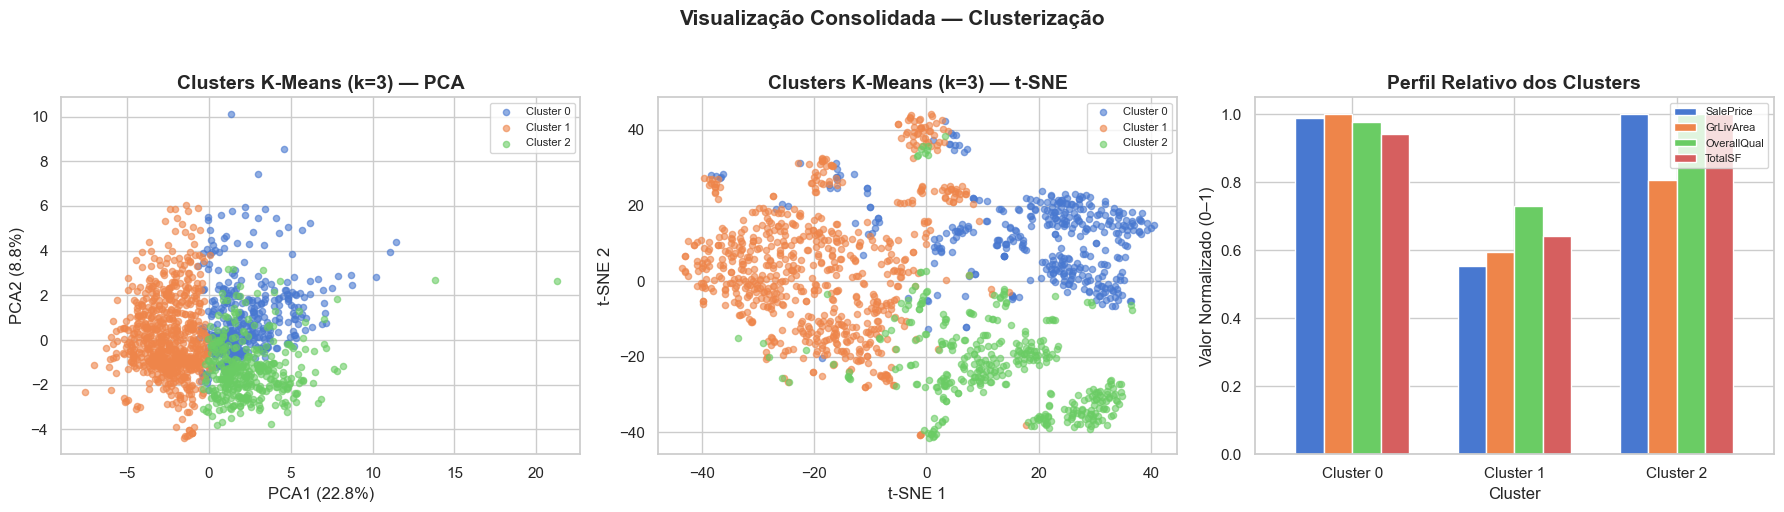

✅ Gráfico salvo: plot_resultados_clusterizacao.png


In [11]:
# ── Clusterização: K-Means + PCA + t-SNE ──
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

df_clust = pd.read_csv('../data/train.csv')

# Features derivadas
df_clust['TotalSF'] = df_clust['TotalBsmtSF'] + df_clust['1stFlrSF'] + df_clust['2ndFlrSF']
df_clust['TotalBathrooms'] = df_clust['FullBath'] + 0.5*df_clust['HalfBath'] + df_clust['BsmtFullBath'] + 0.5*df_clust['BsmtHalfBath']
df_clust['HouseAge'] = (df_clust['YrSold'] - df_clust['YearBuilt']).clip(lower=0)

df_num_c = df_clust.select_dtypes(include=[np.number]).copy()
df_num_c = df_num_c.fillna(df_num_c.median(numeric_only=True))
X_cl = df_num_c.drop(columns=['Id', 'SalePrice'], errors='ignore')

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_cl)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)

# K-Means (k=3 — valor típico do elbow)
# Recalcular elbow para achar k
from numpy.linalg import norm
inertias = []
for k in range(1, 11):
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_sc).inertia_)
pts = np.array(list(zip(range(1,11), inertias)), dtype=float)
line = pts[-1] - pts[0]
line_n = line / norm(line)
dists = [norm((p - pts[0]) - np.dot(p - pts[0], line_n)*line_n) for p in pts]
k_best = int(np.argmax(dists)) + 1

km = KMeans(n_clusters=k_best, random_state=42, n_init=10)
labels = km.fit_predict(X_sc)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sc)

# ── Painel: PCA + t-SNE + Perfil ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
for cl in range(k_best):
    mask = labels == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=20, alpha=0.6, label=f'Cluster {cl}')
axes[0].set_title(f'Clusters K-Means (k={k_best}) — PCA', fontweight='bold')
axes[0].set_xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend(fontsize=8)

# t-SNE
for cl in range(k_best):
    mask = labels == cl
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=20, alpha=0.6, label=f'Cluster {cl}')
axes[1].set_title(f'Clusters K-Means (k={k_best}) — t-SNE', fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(fontsize=8)

# Perfil (barplot de médias)
df_clust['Cluster'] = labels
profile_cols = ['SalePrice', 'GrLivArea', 'OverallQual', 'TotalSF']
cluster_means = df_clust.groupby('Cluster')[profile_cols].mean()
# Normalizar para comparação visual
cluster_norm = cluster_means.div(cluster_means.max())
cluster_norm.plot(kind='bar', ax=axes[2], edgecolor='white', width=0.7)
axes[2].set_title('Perfil Relativo dos Clusters', fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Valor Normalizado (0–1)')
axes[2].legend(fontsize=8, loc='upper right')
axes[2].set_xticklabels([f'Cluster {i}' for i in range(k_best)], rotation=0)

plt.suptitle('Visualização Consolidada — Clusterização', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/plot_resultados_clusterizacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: plot_resultados_clusterizacao.png')

### 6.3 Regras de Associação e Detecção de Outliers

Resumo visual das regras mais fortes do Apriori e dos outliers identificados pelo LOF.

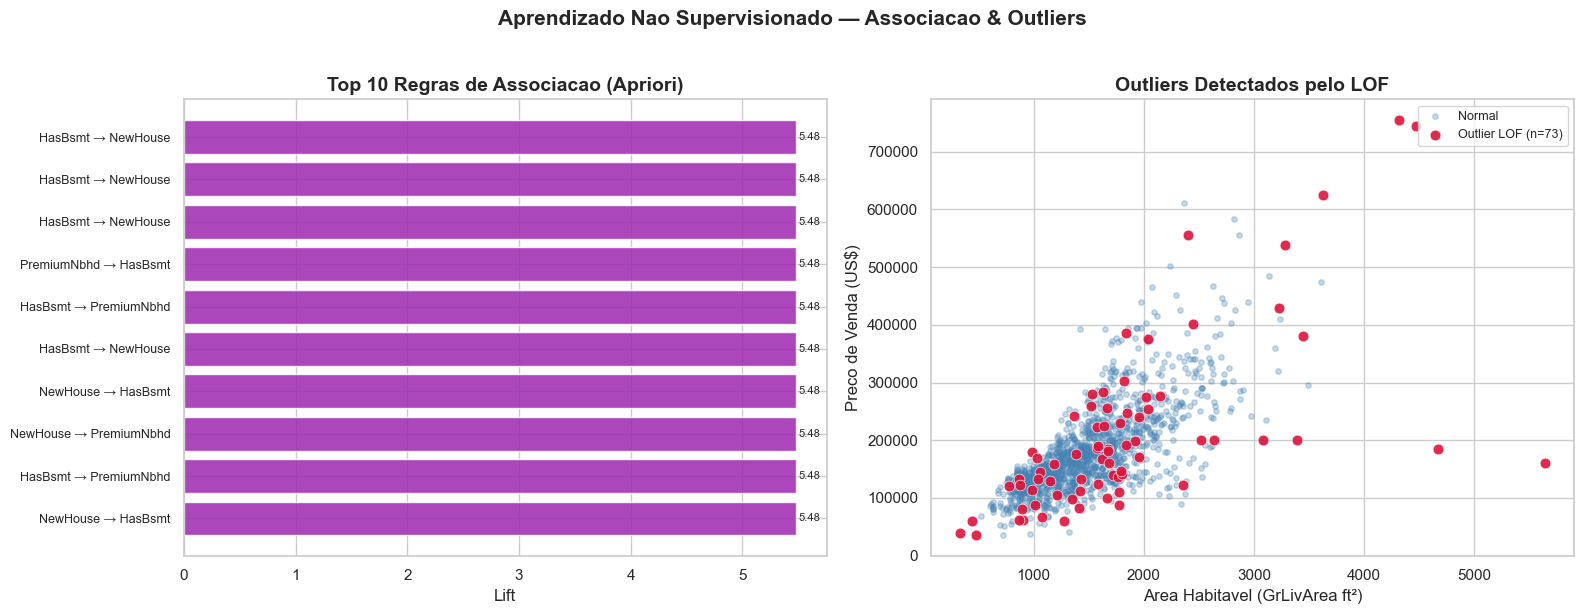

Grafico salvo: plot_resultados_associacao_outliers.png


In [12]:
# ── Apriori + LOF ──
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.neighbors import LocalOutlierFactor

df_assoc = pd.read_csv('../data/train.csv')

# Binarizacao (mesma logica do notebook 05 — cortes por mediana)
def binarize(df):
    items = []

    # OverallQual: mediana
    med_qual = df["OverallQual"].median()
    q33_qual = df["OverallQual"].quantile(0.33)
    items.append(("HighQual", df["OverallQual"] > med_qual))
    items.append(("LowQual",  df["OverallQual"] <= q33_qual))

    # SalePrice: tercis
    q33 = df["SalePrice"].quantile(0.33)
    q66 = df["SalePrice"].quantile(0.66)
    items.append(("PriceHigh", df["SalePrice"] >= q66))
    items.append(("PriceLow",  df["SalePrice"] < q33))

    # GarageArea: mediana
    med_garage = df["GarageArea"].median()
    items.append(("HasGarage", df["GarageArea"] > 0))
    items.append(("BigGarage", df["GarageArea"] >= med_garage))

    # TotalBsmtSF: mediana
    med_bsmt = df["TotalBsmtSF"].median()
    items.append(("HasBsmt",  df["TotalBsmtSF"] > 0))
    items.append(("BigBsmt",  df["TotalBsmtSF"] >= med_bsmt))

    # GrLivArea: tercis
    q66_area = df["GrLivArea"].quantile(0.66)
    items.append(("BigHouse",   df["GrLivArea"] >= q66_area))

    # FullBath: mediana
    med_bath = df["FullBath"].median()
    items.append(("MultiBath", df["FullBath"] >= med_bath))

    # Binarios naturais
    items.append(("HasFireplace", df["Fireplaces"] > 0))
    items.append(("CentralAC",   df["CentralAir"] == "Y"))
    items.append(("GoodKitchen", df["KitchenQual"].isin(["Gd","Ex"])))

    # YearBuilt: mediana
    med_year = df["YearBuilt"].median()
    items.append(("NewHouse", df["YearBuilt"] > med_year))

    # Bairro premium
    top_nb = df.groupby("Neighborhood")["SalePrice"].median().nlargest(5).index
    items.append(("PremiumNbhd", df["Neighborhood"].isin(top_nb)))

    return pd.DataFrame({name: series.astype(bool) for name, series in items})

bin_df = binarize(df_assoc)
freq = apriori(bin_df, min_support=0.05, use_colnames=True)
rules = association_rules(freq, metric="lift", min_threshold=1.2, num_itemsets=len(freq))
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

# LOF
num_cols_lof = ["GrLivArea","TotalBsmtSF","GarageArea","LotArea","OverallQual","SalePrice","1stFlrSF","GarageCars"]
X_lof = df_assoc[num_cols_lof].fillna(0)
X_lof_sc = StandardScaler().fit_transform(X_lof)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_lof_sc)
lof_scores = -lof.negative_outlier_factor_
df_assoc["is_outlier"] = lof_labels == -1

# ── Painel: Top regras + Outliers ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 regras por Lift
top10_rules = rules.head(10).copy()
top10_rules["rule"] = [f"{list(a)[0]} \u2192 {list(c)[0]}" for a, c in zip(top10_rules["antecedents"], top10_rules["consequents"])]
colors_r = ['#2196F3' if 'PriceHigh' in r else '#FF9800' if 'PriceLow' in r else '#9C27B0' for r in top10_rules["rule"]]
bars = axes[0].barh(range(len(top10_rules)), top10_rules["lift"], color=colors_r, alpha=0.85)
axes[0].set_yticks(range(len(top10_rules)))
axes[0].set_yticklabels(top10_rules["rule"], fontsize=9)
axes[0].set_xlabel("Lift")
axes[0].set_title("Top 10 Regras de Associacao (Apriori)", fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, top10_rules["lift"]):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)

# Outliers (GrLivArea vs SalePrice)
normal = df_assoc[~df_assoc["is_outlier"]]
outlier = df_assoc[df_assoc["is_outlier"]]
n_out = outlier.shape[0]
axes[1].scatter(normal["GrLivArea"], normal["SalePrice"], s=15, alpha=0.3, color='steelblue', label='Normal')
axes[1].scatter(outlier["GrLivArea"], outlier["SalePrice"], s=60, alpha=0.9, color='crimson', label=f'Outlier LOF (n={n_out})', zorder=5, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel("Area Habitavel (GrLivArea ft\u00b2)")
axes[1].set_ylabel("Preco de Venda (US$)")
axes[1].set_title("Outliers Detectados pelo LOF", fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Aprendizado Nao Supervisionado \u2014 Associacao & Outliers', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/plot_resultados_associacao_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvo: plot_resultados_associacao_outliers.png')

---
##  Storytelling — Parte 5: O Que os Modelos Revelam

> Na etapa supervisionada, a **Regressão Linear Múltipla** superou a Simples em todas as métricas,
> confirmando que a combinação de área, qualidade, garagem e banheiros explica muito melhor o preço
> do que apenas a área habitável isoladamente. Na classificação, tanto a Regressão Logística quanto`n> o Random Forest apresentaram desempenho elevado. A Regressão Logística ficou levemente melhor`n> em acurácia e F1-score, enquanto o Random Forest manteve boa precisão e ajuda a capturar`n> possíveis interações não-lineares entre as features.

> Na etapa não supervisionada, a **clusterização K-Means** identificou grupos interpretáveis de imóveis
> — desde casas populares (menores, mais antigas, qualidade média) até imóveis premium (grandes,
> recentes, alta qualidade). O **Apriori** revelou que casas de alta qualidade em bairros premium
> estão fortemente associadas a preços altos, enquanto o **LOF** detectou anomalias em imóveis
> com características extremas (área muito grande com preço muito baixo, ou vice-versa).


---
## Storytelling — Conclusão Final

### Síntese executiva do projeto

Ao longo deste projeto, analisamos o dataset **House Prices: Advanced Regression Techniques**, com informações estruturais, temporais e qualitativas de imóveis vendidos em Ames, Iowa. A análise mostrou que o preço das casas é explicado principalmente pela combinação entre **qualidade geral**, **área habitável**, **área total construída**, **estrutura de garagem/porão** e **idade ou atualização do imóvel**.

Na etapa de **feature engineering**, o dataset foi enriquecido com variáveis como `TotalSF`, `TotalBathrooms`, `HouseAge`, `YearsSinceRemodel` e indicadores de presença de garagem, porão, lareira e piscina. Essas variáveis ajudam os modelos porque condensam informações espalhadas em sinais mais próximos da lógica imobiliária: tamanho, conforto, conservação e atributos valorizados.

Na **regressão**, a Regressão Linear Múltipla superou a Regressão Linear Simples porque combina diversos fatores que influenciam o preço. A leitura principal é que usar apenas área habitável captura uma parte importante do problema, mas variáveis de qualidade, área total, garagem, banheiros e idade aumentam a capacidade explicativa do modelo.

Na **classificação**, o preço foi convertido em uma variável binária usando a mediana como corte entre imóveis baratos e caros. Os modelos de Regressão Logística e Random Forest apresentaram desempenho alto e comparável, mostrando que as características disponíveis são suficientes para separar bem imóveis acima e abaixo da mediana de preço.

Na **clusterização**, o K-Means encontrou perfis interpretáveis de casas. O PCA e o t-SNE foram usados como visualizações em menor dimensão; o PCA explica apenas parte da variância total, então sua função é apoiar a leitura visual, não substituir a base original. O Silhouette Score positivo, mas baixo, indica grupos moderadamente separados, algo coerente para dados imobiliários com grande sobreposição de características.

Nas etapas de **associação e outliers**, o Apriori revelou combinações frequentes de características, como relações entre casas maiores, bairros premium e garagens maiores. O LOF identificou imóveis anômalos, úteis para entender casos extremos que podem distorcer modelos e interpretações.

### Conclusão geral

O trabalho mostra um fluxo completo de análise de dados e aprendizado de máquina: exploração, tratamento, engenharia de features, regressão, classificação, clusterização, redução de dimensionalidade, regras de associação, detecção de outliers e visualização. A principal conclusão é que o preço das casas não depende de uma única variável, mas de um conjunto de fatores estruturais e qualitativos que, quando combinados, permitem prever e interpretar melhor o mercado analisado.


## 📁 Arquivos Gerados

| Arquivo | Descrição |
|---|---|
| `plot_distribuicao_saleprice.png` | Distribuição da variável alvo |
| `plot_distribuicoes_features.png` | Distribuição das principais features |
| `plot_heatmap_correlacoes.png` | Mapa de calor de correlações |
| `plot_scatter_area_preco.png` | Área habitável vs preço |
| `plot_boxplot_qualidade_preco.png` | Qualidade geral vs preço |
| `plot_scatter_ano_preco.png` | Ano de construção vs preço |
| `plot_painel_consolidado.png` | Painel completo do projeto |
| `plot_resultados_supervisionados.png` | Métricas consolidadas de regressão e classificação |
| `plot_resultados_clusterizacao.png` | Clusters PCA + t-SNE + perfil |
| `plot_resultados_associacao_outliers.png` | Regras de associação + outliers LOF |